In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import matplotlib as mpl
import warnings 
warnings.filterwarnings("ignore")





In [2]:
ironman_path = "../datasets/Half_Ironman_df6.csv"
df = pd.read_csv(ironman_path)
df['count'] = 1
df_men = df[df['Gender']== 'M']
df_amateur = df_men[df_men['AgeGroup'] != '00']
df_pro = df_men[df_men['AgeGroup'] == '00']

In [3]:
time_cols = ['SwimTime', 'BikeTime', 'RunTime', 'FinishTime']
overall_rank_cols = []
yearly_rank_cols = []
for col in time_cols: 
    #assign a percentile rank to each row for each time 
    df_amateur[col + '_overall_rank'] = df_amateur[col].rank(pct=True)*100
    overall_rank_cols.append(col + '_overall_rank')




In [4]:

#set order of age groups 
age_order = ['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64']
df_amateur_workingage = df_amateur[df_amateur['AgeGroup'].isin(age_order)]
df_amateur_workingage['AgeGroup'] = pd.Categorical(df_amateur_workingage['AgeGroup'], categories=age_order, ordered=True)
df_amateur_workingage['Performance_category'] = pd.cut(df_amateur_workingage['FinishTime_overall_rank'], bins=[0,5,20,40,60,100], labels=['Elite', 'Sub-Elite', 'Above Average', 'Average', 'Below Average'])


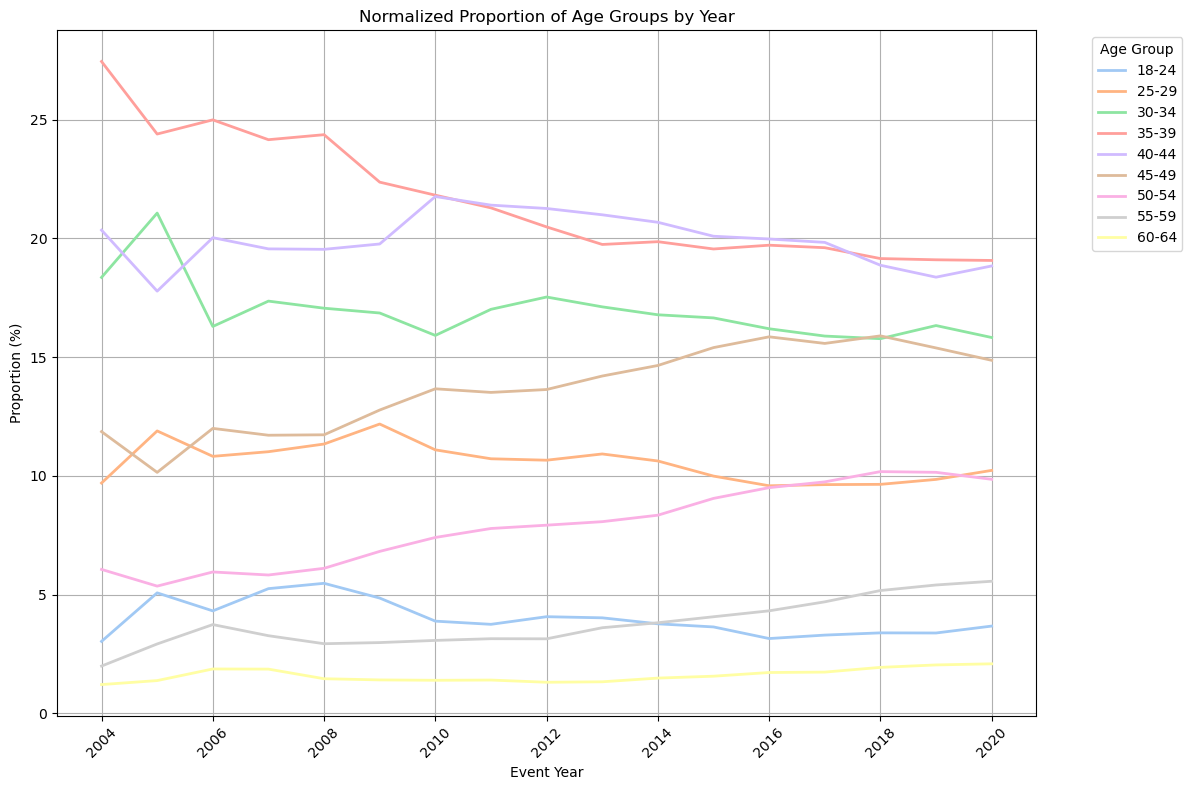

In [5]:
age_dist_year = df_amateur_workingage[['EventYear', 'AgeGroup', 'count']].groupby(['EventYear', 'AgeGroup']).sum()

#normalize counts and plot distributions 
total_agegroup_counts_year = age_dist_year.groupby('EventYear')['count'].sum().reset_index()
age_dist_year['total'] = (age_dist_year.index.get_level_values('EventYear').map(total_agegroup_counts_year.set_index('EventYear')['count'])).astype(int)
age_dist_year['proportion'] = age_dist_year['count']/age_dist_year['total']*100
age_dist_year.reset_index(inplace=True)
pivot_df = age_dist_year.pivot(index='EventYear', columns='AgeGroup', values='proportion')
#set order of age groups 
age_order = ['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64']
palette = sns.color_palette("pastel", len(age_order))
sns.set_palette(palette)

plt.figure(figsize=(12, 8))
for column in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[column], marker='', linewidth=2, label=column)

plt.title('Normalized Proportion of Age Groups by Year')
plt.xlabel('Event Year')
plt.ylabel('Proportion (%)')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()

#agestandardize to 2019 


In [6]:
pivot_df

AgeGroup,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64
EventYear,,,,,,,,,
2004,3.030303,9.696970,18.354978,27.445887,20.346320,11.861472,6.060606,1.991342,1.212121
2005,5.073052,11.891234,21.063312,24.391234,17.775974,10.146104,5.357143,2.922078,1.379870
2006,4.314721,10.821412,16.289802,24.988463,20.027688,11.998154,5.952930,3.737886,1.868943
2007,5.250644,11.016445,17.356846,24.152962,19.556172,11.709927,5.825243,3.269269,1.862493
2008,5.475458,11.339705,17.058156,24.364167,19.536692,11.728495,6.107241,2.932124,1.457962
2009,4.854687,12.181744,16.856324,22.365944,19.762587,12.771183,6.819484,2.979943,1.408105
2010,3.882320,11.094072,15.912668,21.816861,21.760362,13.664797,7.405464,3.071149,1.392308
2011,3.748437,10.718752,17.011124,21.282828,21.398012,13.512802,7.783190,3.142895,1.401961
2012,4.069457,10.658680,17.529223,20.480671,21.256730,13.634379,7.923073,3.138187,1.309599


In [7]:
#

In [8]:
## What does average mean? 
#45 - 55th percentile 
df_amateur_yearly_avg = pd.DataFrame(df_amateur['EventYear'].unique()).rename(columns={0:'EventYear'})
for i in range (0,60,5): 
    for col in time_cols: 
        colname = col + '_'+str(100-i)+'_percentile'
        quantile_data = df_amateur.groupby(['EventYear'])[col].quantile(i/100).reset_index()
        #convert to hh:mm:ss format 
        quantile_data.rename(columns={col:colname}, inplace=True)
        df_amateur_yearly_avg = pd.merge(df_amateur_yearly_avg, quantile_data, on='EventYear', how='left')
#sort by event year 
df_amateur_yearly_avg = df_amateur_yearly_avg.sort_values(by='EventYear')


df_pro_yearly_avg = pd.DataFrame(df_pro['EventYear'].unique()).rename(columns={0:'EventYear'})
for i in range (0,60,5): 
    for col in time_cols: 
        colname = col + '_'+str(100-i)+'_percentile'
        quantile_data = df_pro.groupby(['EventYear'])[col].quantile(i/100).reset_index()
        #convert to hh:mm:ss format 
        quantile_data.rename(columns={col:colname}, inplace=True)
        df_pro_yearly_avg = pd.merge(df_pro_yearly_avg, quantile_data, on='EventYear', how='left')
#sort by event year 
df_pro_yearly_avg = df_pro_yearly_avg.sort_values(by='EventYear')


<AxesSubplot:xlabel='EventYear', ylabel='FinishTime_50_percentile'>

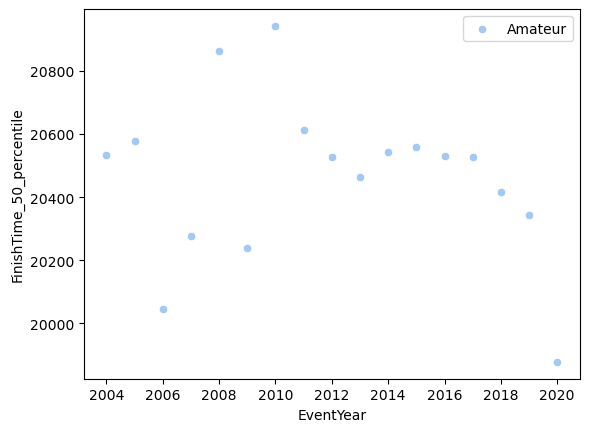

In [9]:
#scatter plot of event year by 50th percentile times 
sns.scatterplot(data=df_amateur_yearly_avg, x='EventYear', y='FinishTime_50_percentile', label='Amateur')

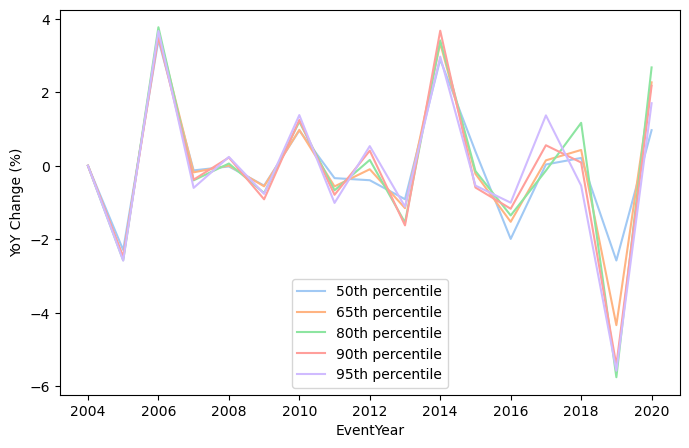

In [10]:
df_amateur_yearly_avg.reset_index(drop=True)
yoy_change_df = pd.DataFrame(df_amateur_yearly_avg['EventYear']).rename(columns={0:'EventYear'}).reset_index(drop=True)
for j in [50,65,80,90,95]: 
    colname = 'FinishTime_'+str(j)+'_percentile'
    yoy_change_list = [0]
    for i in range (1,len(df_amateur_yearly_avg['EventYear'])):
        yoy_change = (df_amateur_yearly_avg.loc[i, colname]/df_amateur_yearly_avg.loc[i-1, colname]-1)*100
        yoy_change_list.append(yoy_change)
    yoy_colname = 'yoy_change_{}pct'.format(j)
    yoy_change_df[yoy_colname] = yoy_change_list

yoy_change_df_long = pd.melt(yoy_change_df, id_vars=['EventYear'], value_vars=['yoy_change_50pct', 'yoy_change_65pct', 'yoy_change_80pct', 'yoy_change_90pct', 'yoy_change_95pct'], var_name = 'Average Finish Time (percentile)', value_name = 'YoY Change (%)')
plt.figure(figsize=(8,5))
sns.lineplot(data=yoy_change_df_long, x='EventYear', y='YoY Change (%)', hue='Average Finish Time (percentile)')
legend_labels = ['50th percentile', '65th percentile', '80th percentile', '90th percentile', '95th percentile']
plt.legend(loc='lower center', labels = legend_labels)


#average yearly change in finish time for amateur athletes by percentile 
#remove first row 

avg_change_df_pct = yoy_change_df[1:][['yoy_change_50pct','yoy_change_65pct','yoy_change_80pct','yoy_change_90pct','yoy_change_95pct']].agg(['mean', 'median'])

In [11]:
avg_change_df_pct

,yoy_change_50pct,yoy_change_65pct,yoy_change_80pct,yoy_change_90pct,yoy_change_95pct
mean,-0.019772,-0.021941,-0.054345,-0.092420,-0.117380
median,-0.072977,-0.137429,-0.138809,-0.145364,-0.540181


In [12]:

#plot yoy_change distributions 

In [13]:
df_amateur_yearly_avg.columns


Index(['EventYear', 'SwimTime_100_percentile', 'BikeTime_100_percentile',
       'RunTime_100_percentile', 'FinishTime_100_percentile',
       'SwimTime_95_percentile', 'BikeTime_95_percentile',
       'RunTime_95_percentile', 'FinishTime_95_percentile',
       'SwimTime_90_percentile', 'BikeTime_90_percentile',
       'RunTime_90_percentile', 'FinishTime_90_percentile',
       'SwimTime_85_percentile', 'BikeTime_85_percentile',
       'RunTime_85_percentile', 'FinishTime_85_percentile',
       'SwimTime_80_percentile', 'BikeTime_80_percentile',
       'RunTime_80_percentile', 'FinishTime_80_percentile',
       'SwimTime_75_percentile', 'BikeTime_75_percentile',
       'RunTime_75_percentile', 'FinishTime_75_percentile',
       'SwimTime_70_percentile', 'BikeTime_70_percentile',
       'RunTime_70_percentile', 'FinishTime_70_percentile',
       'SwimTime_65_percentile', 'BikeTime_65_percentile',
       'RunTime_65_percentile', 'FinishTime_65_percentile',
       'SwimTime_60_percentile'

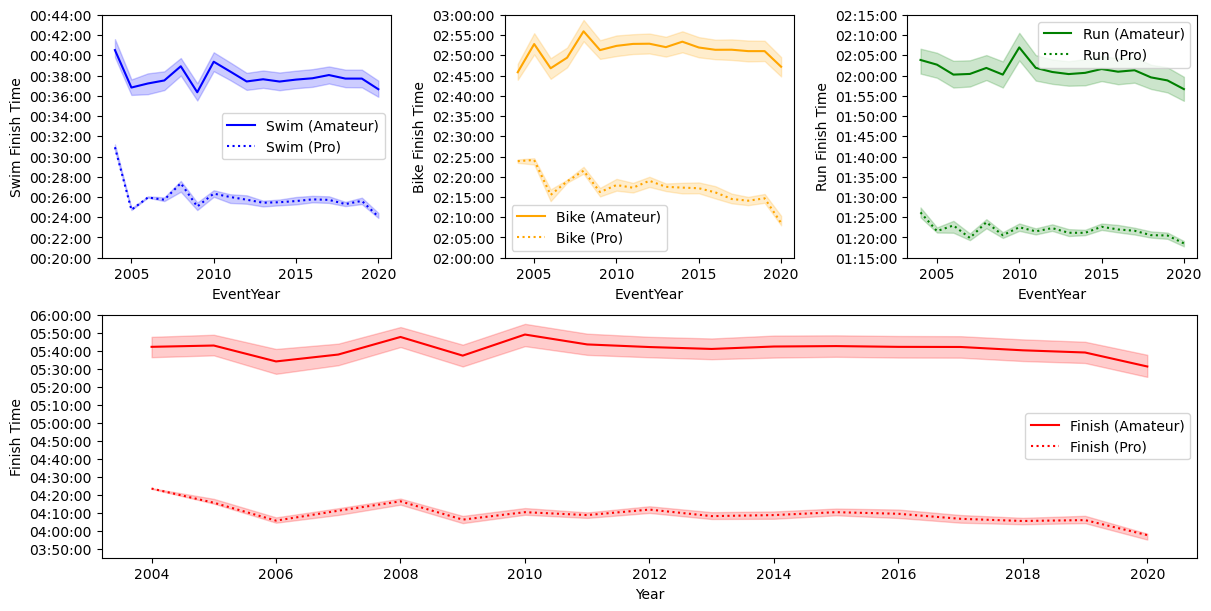

In [14]:
def seconds_to_hhmmss(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    seconds = seconds % 60
    return f'{int(hours):02}:{int(minutes):02}:{int(seconds):02}'

#plot above average 55th to 69th percentile finish times 
#create plot, size 5, 10
axs = plt.figure(layout = 'constrained', figsize= (12,6)).subplot_mosaic(
    """ABC;DDD"""
    )
#plot above average 55th to 69th percentile finish times

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'SwimTime_50_percentile', label = 'Swim (Amateur)', color = 'blue', ax=axs['A'])
axs['A'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['SwimTime_45_percentile'], df_amateur_yearly_avg['SwimTime_55_percentile'], alpha=0.2, color = 'blue')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'SwimTime_50_percentile', label = 'Swim (Pro)', linestyle='dotted', color = 'blue', ax = axs['A'])
axs['A'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['SwimTime_45_percentile'], df_pro_yearly_avg['SwimTime_55_percentile'], alpha=0.2, color = 'blue')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'BikeTime_50_percentile', label = 'Bike (Amateur)', color = 'orange', ax = axs['B'])
axs['B'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['BikeTime_45_percentile'], df_amateur_yearly_avg['BikeTime_55_percentile'], alpha=0.2, color = 'orange')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'BikeTime_50_percentile', label = 'Bike (Pro)', linestyle='dotted', color = 'orange', ax = axs['B'])
axs['B'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['BikeTime_45_percentile'], df_pro_yearly_avg['BikeTime_55_percentile'], alpha=0.2, color = 'orange')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'RunTime_50_percentile', label = 'Run (Amateur)', color = 'green', ax = axs['C'])
axs['C'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['RunTime_45_percentile'], df_amateur_yearly_avg['RunTime_55_percentile'], alpha=0.2, color = 'green')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'RunTime_50_percentile', label = 'Run (Pro)', linestyle='dotted', color = 'green', ax = axs['C'])
axs['C'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['RunTime_45_percentile'], df_pro_yearly_avg['RunTime_55_percentile'], alpha=0.2, color = 'green')

sns.lineplot(data = df_amateur_yearly_avg, x = 'EventYear', y = 'FinishTime_50_percentile', label = 'Finish (Amateur)', color = 'red', ax = axs['D'])
axs['D'].fill_between(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg['FinishTime_45_percentile'], df_amateur_yearly_avg['FinishTime_55_percentile'], alpha=0.2, color = 'red')
sns.lineplot(data = df_pro_yearly_avg, x = 'EventYear', y = 'FinishTime_50_percentile', label = 'Finish (Pro)', linestyle='dotted', color = 'red', ax = axs['D'])
axs['D'].fill_between(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg['FinishTime_45_percentile'], df_pro_yearly_avg['FinishTime_55_percentile'], alpha=0.2, color = 'red')

from matplotlib.ticker import FuncFormatter, MultipleLocator
formatter = FuncFormatter(lambda x, _: seconds_to_hhmmss(x))
axs['A'].yaxis.set_major_formatter(formatter)
axs['A'].yaxis.set_major_locator(MultipleLocator(base=120))
axs['A'].set_ylabel('Swim Finish Time')
axs['A'].set_ylim(1200,2640)
axs['B'].yaxis.set_major_formatter(formatter)
axs['B'].yaxis.set_major_locator(MultipleLocator(base=300))
axs['B'].set_ylabel('Bike Finish Time')
axs['B'].set_ylim(7200,10800)
axs['C'].yaxis.set_major_formatter(formatter)
axs['C'].yaxis.set_major_locator(MultipleLocator(base=300))
axs['C'].set_ylabel('Run Finish Time')
axs['C'].set_ylim(4500,8100)
axs['D'].yaxis.set_major_formatter(formatter)
axs['D'].yaxis.set_major_locator(MultipleLocator(base=600))
axs['D'].set_ylim(13500,21600)

plt.ylabel('Finish Time')
plt.xlabel('Year')
# sns.move_legend(, "upper left", bbox_to_anchor=(1, 1))
#Convert seconds to hours, mm and

# # Combine legends from all subplots into one
# handles, labels = axs[0].get_legend_handles_labels()
# plt.tight_layout(rect=[0.05, 0.1, 0.95, 0.95])
plt.show()

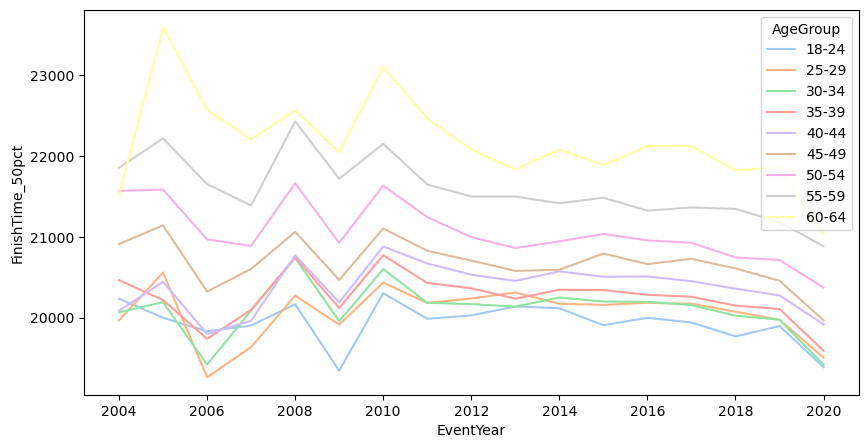

In [15]:
#find age group distributions where the middle 50% of finish times  are 
df_working_age = df_amateur[df_amateur['AgeGroup'].isin(['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64'])]
plt.figure(figsize=(10,5))
agegrp_mid = df_working_age[['EventYear', 'AgeGroup', 'FinishTime']].groupby(['EventYear', 'AgeGroup'])['FinishTime'].quantile([0.45, 0.5, 0.55]).unstack().reset_index()
agegrp_mid.rename(columns={0.45:'FinishTime_45pct', 0.5:'FinishTime_50pct', 0.55:'FinishTime_55pct'}, inplace=True)

#plot average finish times across the years, across the different age groups 
agegrp_plot = sns.lineplot(data = agegrp_mid, x = 'EventYear', y = 'FinishTime_50pct', hue = 'AgeGroup')


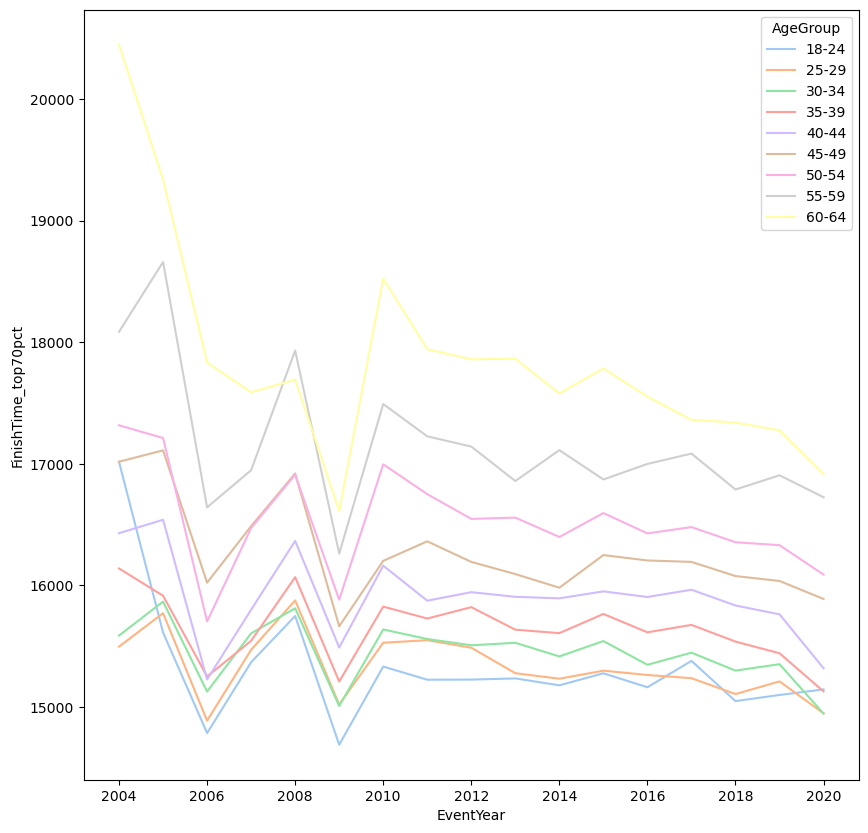

In [16]:
#find age group distributions where the middle 50% of finish times  are 
plt.figure(figsize=(10,10))
agegrp_abvabg = df_working_age[['EventYear', 'AgeGroup', 'FinishTime']].groupby(['EventYear', 'AgeGroup'])['FinishTime'].quantile([0.2, 0.1, 0.01]).unstack().reset_index()
agegrp_abvabg.rename(columns={0.2:'FinishTime_top60pct', 0.1:'FinishTime_top65pct', 0.01:'FinishTime_top70pct'}, inplace=True)
#plot average finish times across the years, across the different age groups 
agegrp_plot = sns.lineplot(data = agegrp_abvabg, x = 'EventYear', y = 'FinishTime_top70pct', hue = 'AgeGroup')


In [17]:
df_pro

,Gender,AgeGroup,AgeBand,Country,CountryISO2,EventYear,EventLocation,SwimTime,Transition1Time,BikeTime,Transition2Time,RunTime,FinishTime,count
424,M,00,0,United Arab Emirates,AE,2011,IRONMAN 70.3 Asia-Pacific,1433,96,8638,105,4837,15109,1
477,M,00,0,United Arab Emirates,AE,2012,IRONMAN 70.3 World Championship,1449,163,7985,74,4936,14607,1
802,M,00,0,Argentina,AR,2019,IRONMAN 70.3 South American Championship Bueno...,1385,82,7736,67,4735,14006,1
803,M,00,0,Argentina,AR,2019,IRONMAN 70.3 South American Championship Bueno...,1620,94,7741,74,4635,14164,1
835,M,00,0,Argentina,AR,2019,IRONMAN 70.3 South American Championship Bueno...,1752,123,8504,94,5813,16285,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838622,M,00,0,South Africa,ZA,2015,IRONMAN 70.3 South Africa,1671,179,10014,157,5053,17074,1
839832,M,00,0,South Africa,ZA,2015,IRONMAN 70.3 St. George,1559,120,7968,61,4776,14484,1
839848,M,00,0,South Africa,ZA,2015,IRONMAN 70.3 Budapest,1693,114,7923,104,4190,14024,1
839908,M,00,0,South Africa,ZA,2015,IRONMAN 70.3 Switzerland,1437,115,8780,80,5366,15778,1


In [18]:
agegrp_abvabg

,EventYear,AgeGroup,FinishTime_top60pct,FinishTime_top65pct,FinishTime_top70pct
0,2004,18-24,18329.2,17289.2,17015.96
1,2004,25-29,18193.2,16926.9,15496.41
2,2004,30-34,17947.4,17352.0,15587.51
3,2004,35-39,18296.0,17495.6,16139.28
4,2004,40-44,18149.4,17504.4,16429.06
...,...,...,...,...,...
148,2020,40-44,17647.2,16801.2,15318.56
149,2020,45-49,17813.6,17092.2,15888.42
150,2020,50-54,18107.4,17434.8,16088.40
151,2020,55-59,18803.4,17844.8,16724.53


In [19]:
agegrp_mid

,EventYear,AgeGroup,FinishTime_45pct,FinishTime_50pct,FinishTime_55pct
0,2004,18-24,19629.80,20234.0,20777.50
1,2004,25-29,19729.25,19968.0,20438.15
2,2004,30-34,19790.70,20066.0,20358.25
3,2004,35-39,20033.60,20465.0,20783.80
4,2004,40-44,19750.80,20085.0,20642.30
...,...,...,...,...,...
148,2020,40-44,19558.70,19917.0,20288.60
149,2020,45-49,19595.20,19967.0,20349.90
150,2020,50-54,20023.20,20372.0,20641.80
151,2020,55-59,20578.00,20884.5,21291.00


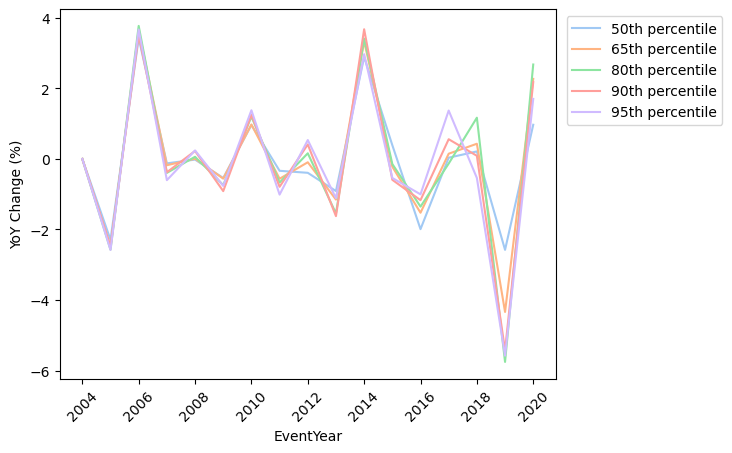

In [30]:

yoy_change_df = pd.DataFrame(df_amateur_yearly_avg['EventYear']).rename(columns={0:'EventYear'}).reset_index(drop=True)
for j in [50,65,80,90,95]: 
    colname = 'FinishTime_'+str(j)+'_percentile'
    yoy_change_list = [0]
    for i in range (1,len(df_amateur_yearly_avg['EventYear'])):
        yoy_change = (df_amateur_yearly_avg.loc[i, colname]/df_amateur_yearly_avg.loc[i-1, colname]-1)*100
        yoy_change_list.append(yoy_change)
    yoy_colname = 'yoy_change_{}pct'.format(j)
    yoy_change_df[yoy_colname] = yoy_change_list

yoy_change_df_long = pd.melt(yoy_change_df, id_vars=['EventYear'], value_vars=['yoy_change_50pct', 'yoy_change_65pct', 'yoy_change_80pct', 'yoy_change_90pct', 'yoy_change_95pct'], var_name = 'Average Finish Time (percentile)', value_name = 'YoY Change (%)')
sns.lineplot(data=yoy_change_df_long, x='EventYear', y='YoY Change (%)', hue='Average Finish Time (percentile)')
legend_labels = ['50th percentile', '65th percentile', '80th percentile', '90th percentile', '95th percentile']
plt.legend(loc='upper right', labels = legend_labels, bbox_to_anchor = (1.35,1))
plt.xticks(rotation=45)
plt.show()


In [38]:
df_amateur_yearly_avg

,EventYear,SwimTime_100_percentile,BikeTime_100_percentile,RunTime_100_percentile,FinishTime_100_percentile,SwimTime_95_percentile,BikeTime_95_percentile,RunTime_95_percentile,FinishTime_95_percentile,SwimTime_90_percentile,...,RunTime_55_percentile,FinishTime_55_percentile,SwimTime_50_percentile,BikeTime_50_percentile,RunTime_50_percentile,FinishTime_50_percentile,SwimTime_45_percentile,BikeTime_45_percentile,RunTime_45_percentile,FinishTime_45_percentile
13,2004,1572.0,8166.0,4759.0,14849.0,1861.4,8732.20,5680.70,16996.60,1949.4,...,7228.90,20186.90,2431.0,9949.0,7431.0,20533.0,2496.0,10073.4,7598.1,20866.00
14,2005,1422.0,7966.0,4623.0,15314.0,1685.0,8827.45,5499.90,16904.80,1800.9,...,7167.05,20248.05,2209.0,10367.0,7361.5,20576.5,2257.0,10527.9,7537.8,20935.80
15,2006,1259.0,7573.0,4496.0,14355.0,1677.0,8125.00,5418.50,15962.00,1784.0,...,7022.00,19632.50,2233.0,10008.0,7214.0,20046.0,2293.0,10157.0,7418.5,20462.50
9,2007,1205.0,7552.0,4254.0,14273.0,1693.0,8755.00,5405.20,16538.00,1786.0,...,7037.00,19918.80,2251.0,10165.0,7224.0,20276.0,2305.0,10315.0,7426.2,20639.00
10,2008,1308.0,7413.0,4021.0,14913.0,1739.0,8945.00,5531.60,17029.00,1864.0,...,7133.00,20524.40,2335.0,10556.0,7313.0,20862.0,2384.0,10724.8,7503.8,21192.80
16,2009,1214.0,7373.0,4182.0,13895.0,1584.0,8387.00,5401.00,16233.50,1685.0,...,7022.50,19878.00,2181.0,10277.0,7214.0,20240.0,2234.0,10424.0,7410.0,20605.50
11,2010,1230.0,6887.0,4030.0,14272.0,1709.0,8801.00,5579.20,16937.00,1833.0,...,7424.00,20555.00,2362.0,10340.0,7617.0,20943.0,2418.0,10494.2,7833.2,21299.20
6,2011,1210.0,7156.0,4068.0,14009.0,1673.0,8832.00,5470.00,16805.50,1795.0,...,7125.00,20264.00,2304.0,10369.0,7314.0,20613.0,2358.0,10513.0,7503.0,20972.00
12,2012,1201.0,6511.0,4010.0,13449.0,1661.0,8733.00,5521.00,16766.80,1775.0,...,7077.00,20184.20,2245.0,10372.0,7253.0,20526.0,2296.0,10523.0,7438.0,20867.00
8,2013,1242.0,6648.0,4017.0,14120.0,1678.0,8772.00,5461.00,16724.35,1792.0,...,7049.00,20120.00,2258.0,10321.0,7222.0,20462.5,2310.0,10475.0,7412.0,20812.00


In [54]:
from IPython.display import Markdown 
from tabulate import tabulate
finishers_yearly = df_amateur.groupby('EventYear')['count'].sum().reset_index()
yoy_change_df['total_finishers'] = finishers_yearly['count']
yoy_change_df

#plot regression line for each percentile vs event year 
from scipy.stats import pearsonr, linregress
finish_percentile_col = ['FinishTime_50_percentile', 'FinishTime_65_percentile', 'FinishTime_80_percentile', 'FinishTime_90_percentile', 'FinishTime_95_percentile']

#calculate correlation coefficient for each percentile
df_eventyear_finish_corr = pd.DataFrame()
for col in finish_percentile_col: 
    pro_corr = pearsonr(df_pro_yearly_avg['EventYear'], df_pro_yearly_avg[col])
    amateur_corr = pearsonr(df_amateur_yearly_avg['EventYear'], df_amateur_yearly_avg[col])
    pro_results = (pro_corr[0], pro_corr[1])
    amateur_results = (amateur_corr[0], amateur_corr[1])
    df_eventyear_finish_corr = df_eventyear_finish_corr.append({'Percentile':col, 'R Value (Pro)':pro_results[0], 'P-Value (Pro)':pro_results[1], 'R Value (Amateur)':amateur_results[0], 'P-Value (Amateur)':amateur_results[1]}, ignore_index=True)
    
Markdown(tabulate(df_eventyear_finish_corr))


#plot regression line for each avg percentile against event years 




|    | Percentile               |   R Value (Pro) |   P-Value (Pro) |   R Value (Amateur) |   P-Value (Amateur) |
|---:|:-------------------------|----------------:|----------------:|--------------------:|--------------------:|
|  0 | FinishTime_50_percentile |       -0.705056 |     0.00157193  |           -0.224363 |            0.386641 |
|  1 | FinishTime_65_percentile |       -0.720402 |     0.00110658  |           -0.173852 |            0.504567 |
|  2 | FinishTime_80_percentile |       -0.737097 |     0.000735811 |           -0.109345 |            0.676126 |
|  3 | FinishTime_90_percentile |       -0.724633 |     0.00100056  |           -0.115874 |            0.657861 |
|  4 | FinishTime_95_percentile |       -0.720559 |     0.00110249  |           -0.200382 |            0.440627 |

In [55]:
df_eventyear_finish_corr

,Percentile,R Value (Pro),P-Value (Pro),R Value (Amateur),P-Value (Amateur)
0,FinishTime_50_percentile,-0.705056,0.001572,-0.224363,0.386641
1,FinishTime_65_percentile,-0.720402,0.001107,-0.173852,0.504567
2,FinishTime_80_percentile,-0.737097,0.000736,-0.109345,0.676126
3,FinishTime_90_percentile,-0.724633,0.001001,-0.115874,0.657861
4,FinishTime_95_percentile,-0.720559,0.001102,-0.200382,0.440627


['SwimTime', 'BikeTime', 'RunTime', 'FinishTime']

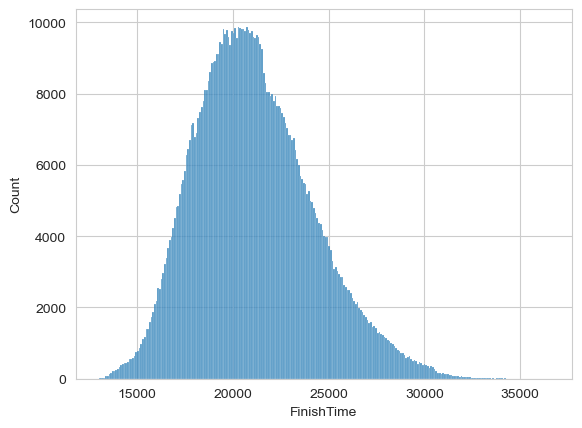

In [ ]:
#plot histogram of finish time 
sns.histplot(df['FinishTime'])


time_cols

In [ ]:
##00 = professionals 

#encoding pro status 
df['Pro_status'] = df['AgeGroup'].apply(lambda x: 1 if x == '00' else 0)
df['AgeGroup'].unique()

array(['40-44', '45-49', '35-39', '50-54', '25-29', '18-24', '30-34',
       '55-59', '00', '60-64', '70-74', '65-69', '75-79', '80-84',
       '85-89'], dtype=object)

In [ ]:
finishers_yeargrp = df[['EventYear', 'Gender', 'count']].groupby(['EventYear', 'Gender']).sum().reset_index()
yeargrp = df[['EventYear', 'Gender', 'count']].groupby(['EventYear']).sum().reset_index() 
yeargrp['Gender'] = 'Total'
finishers_yeargrp = pd.concat([finishers_yeargrp, yeargrp]).reset_index(drop=True)

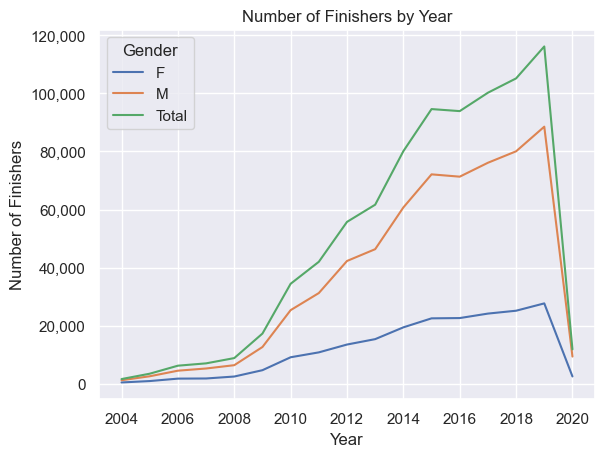

In [ ]:
#plot number of finishers by year 
sns.set_theme(style="darkgrid")
finisher_countplt = sns.lineplot(data=finishers_yeargrp, x='EventYear', y='count', hue='Gender')
finisher_countplt.set(title='Number of Finishers by Year', xlabel='Year', ylabel='Number of Finishers')

# Formatting y-axis
finisher_countplt.get_yaxis().set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))


In [ ]:
#figure out the age